In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path
root_dir = Path("../../../class.vision/")

In [3]:
protoFile = root_dir / "model/caffe/pose_deploy_linevec_faster_4_stages.prototxt"
weightsFile = root_dir / "model/caffe/pose_iter_160000.caffemodel"

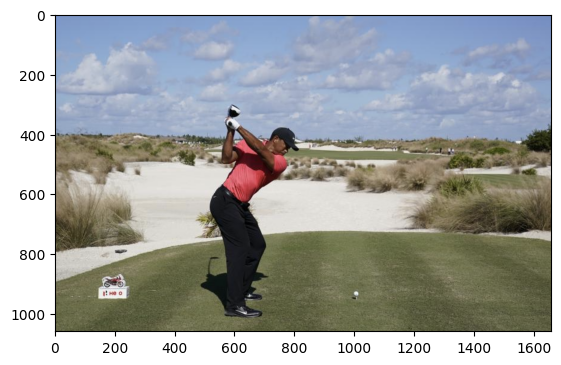

In [4]:
image = cv.imread(root_dir/"images/Tiger_Woods.png")
height, width, _ = image.shape
plt.imshow(image[...,::-1]);

In [5]:
def blob_img(img):
    return cv.dnn.blobFromImage(img, 1.0 / 255, (368, 368), (0, 0, 0), swapRB=False, crop=False)

In [6]:
nPoints = 15
POSE_PAIRS = [[0,1], [1,2], [2,3], [3,4], [1,5], [5,6], [6,7], [1,14], [14,8], [8,9], [9,10], [14,11], [11,12], [12,13] ]

In [7]:
model = cv.dnn.readNetFromCaffe(protoFile, weightsFile)

In [8]:
model.setInput(blob_img(image))

In [9]:
res = model.forward()

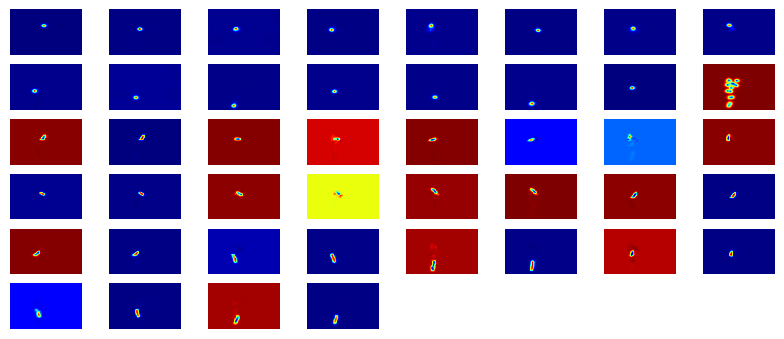

In [10]:
# Display probability maps
plt.figure(figsize=(10,7))
for i in range(res.shape[1]):
    probMap = res[0, i, :, :]
    displayMap = cv.resize(probMap, (width, height), cv.INTER_LINEAR)
    plt.subplot(10, 8, i+1); plt.axis('off'); plt.imshow(displayMap, cmap='jet')

In [11]:
# X and Y Scale
scaleX = width / res.shape[3]
scaleY = height / res.shape[2]

# Empty list to store the detected keypoints
points = []

# Treshold
threshold = 0.1

for i in range(nPoints):
    # Obtain probability map
    probMap = res[0, i, :, :]

    # Find global maxima of the probMap.
    _, prob, _, point = cv.minMaxLoc(probMap)

    # Scale the point to fit on the original image
    x = scaleX * point[0]
    y = scaleY * point[1]

    if prob > threshold :
        # Add the point to the list if the probability is greater than the threshold
        points.append((int(x), int(y)))
    else :
        points.append(None)

In [12]:
imPoints = image.copy()
imSkeleton = image.copy()
# Draw points
for i, p in enumerate(points):
    cv.circle(imPoints, p, 8, (255, 255,0), thickness=-1, lineType=cv.FILLED)
    cv.putText(imPoints, "{}".format(i), p, cv.FONT_HERSHEY_SIMPLEX, 1, (255,0,0), 2, lineType=cv.LINE_AA)

# Draw skeleton
for pair in POSE_PAIRS:
    partA = pair[0]
    partB = pair[1]

    if points[partA] and points[partB]:
        cv.line(imSkeleton, points[partA], points[partB], (255, 255,0), 2)
        cv.circle(imSkeleton, points[partA], 8, (255, 0, 0), thickness=-1, lineType=cv.FILLED)

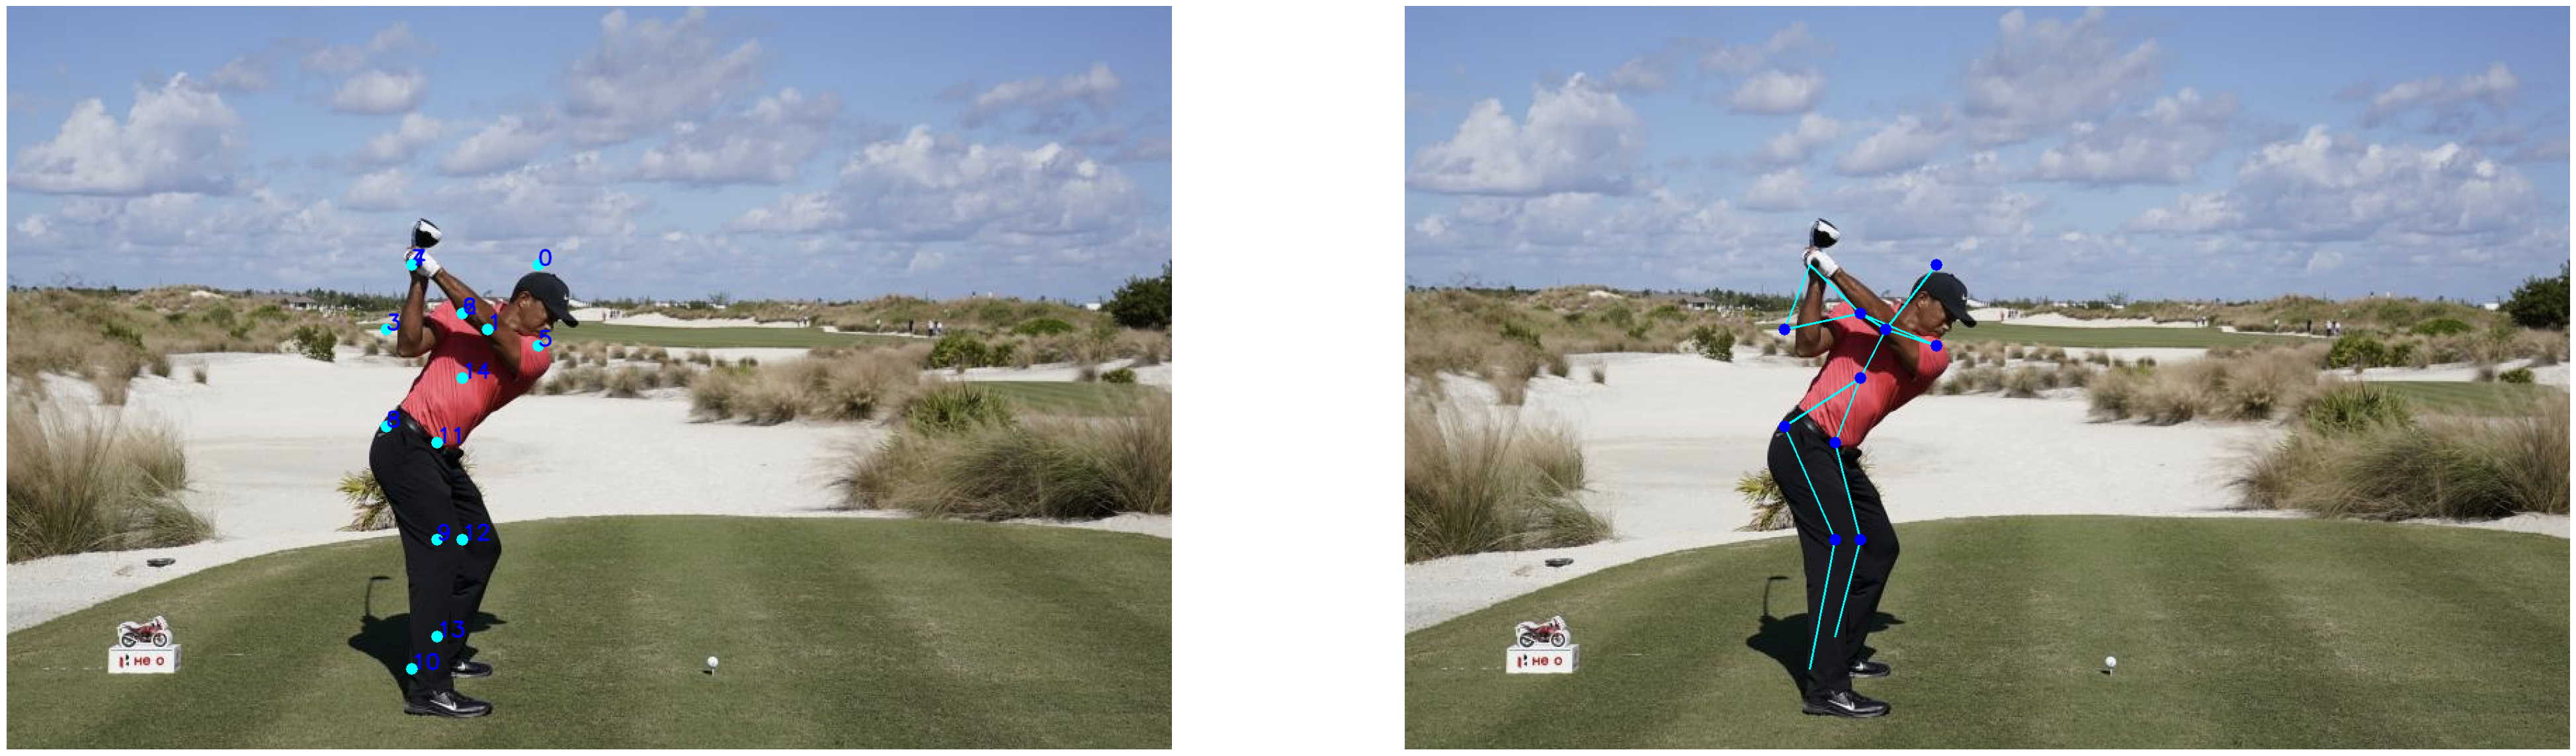

In [13]:
plt.figure(figsize=(50,50))
plt.subplot(121); plt.axis('off'); plt.imshow(imPoints[...,::-1]);
plt.subplot(122); plt.axis('off'); plt.imshow(imSkeleton[...,::-1]);